# Exploratory Data Analysis (EDA)

In [10]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing = pd.read_csv(url)

# Display the first few rows of the dataset
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Summary statistics of numerical variables
print("Summary Statistics of Numerical Variables:")
print(housing.describe())


Summary Statistics of Numerical Variables:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.00

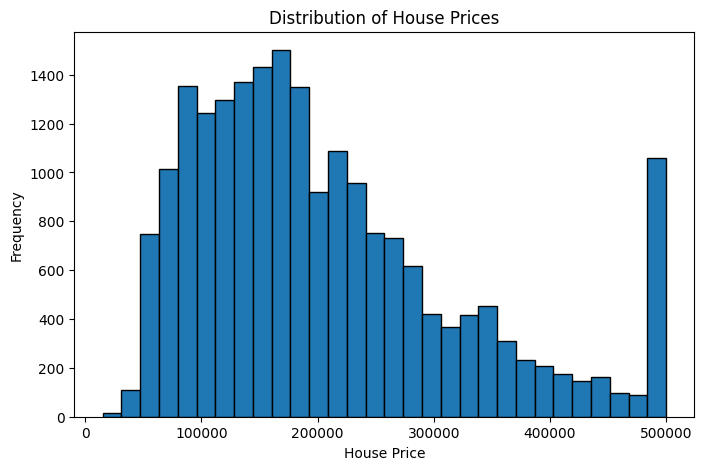

In [5]:
# Plot distribution of house prices (the target variable)
plt.figure(figsize=(8, 5))
plt.hist(housing['median_house_value'], bins=30, edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()


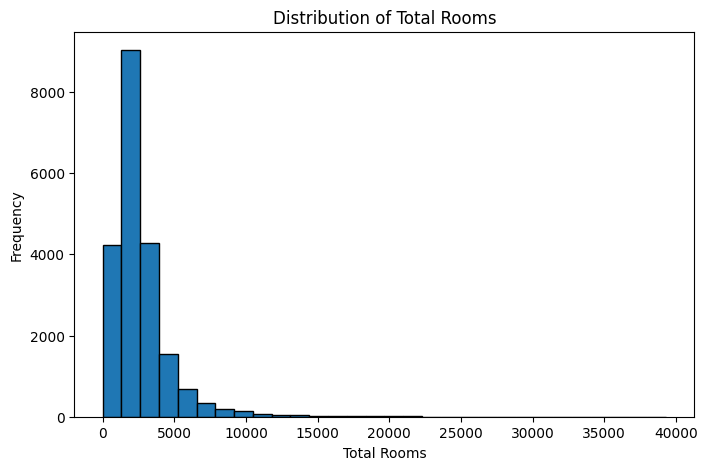

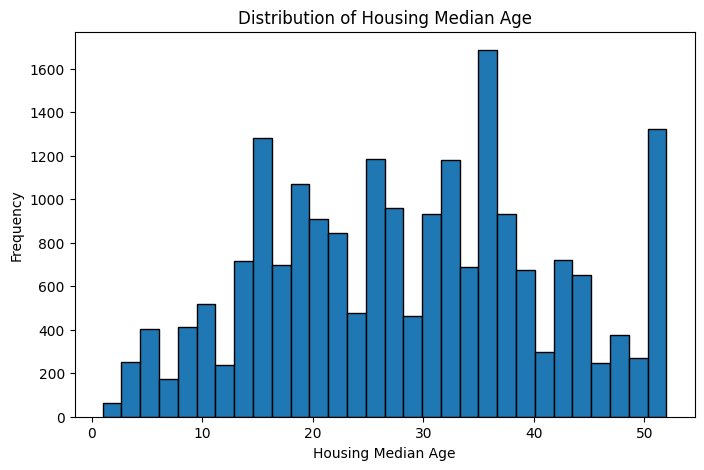

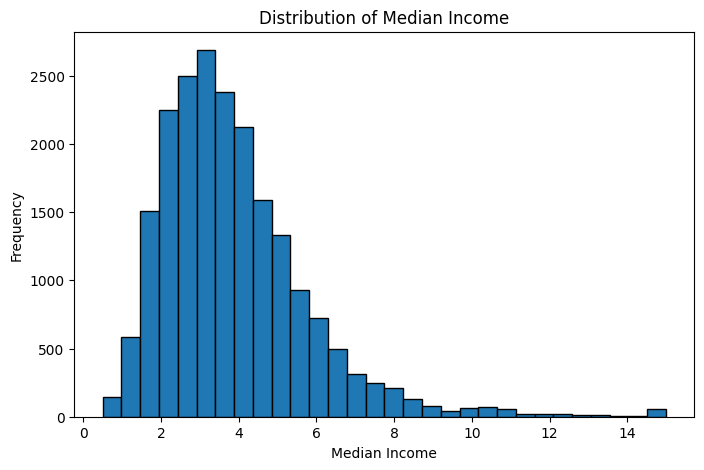

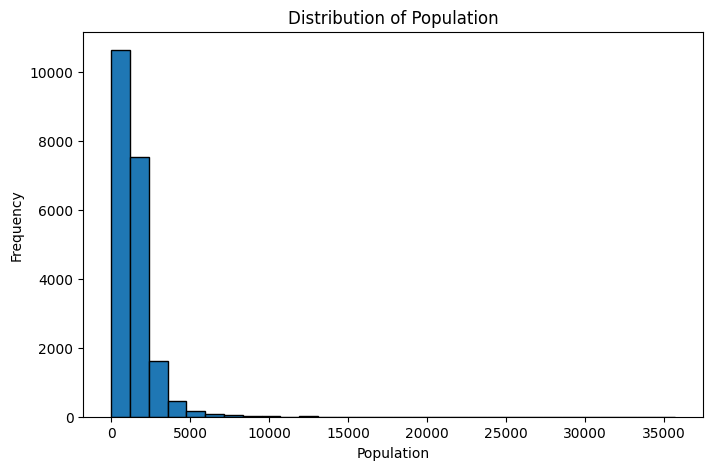

In [6]:
# Create histograms for selected numerical variables (Rooms, Median Age, Median Income, Population)
variables = ['total_rooms', 'housing_median_age', 'median_income', 'population']
for var in variables:
    plt.figure(figsize=(8, 5))
    plt.hist(housing[var], bins=30, edgecolor='black')
    plt.title(f"Distribution of {var.replace('_', ' ').title()}")
    plt.xlabel(var.replace('_', ' ').title())
    plt.ylabel("Frequency")
    plt.show()

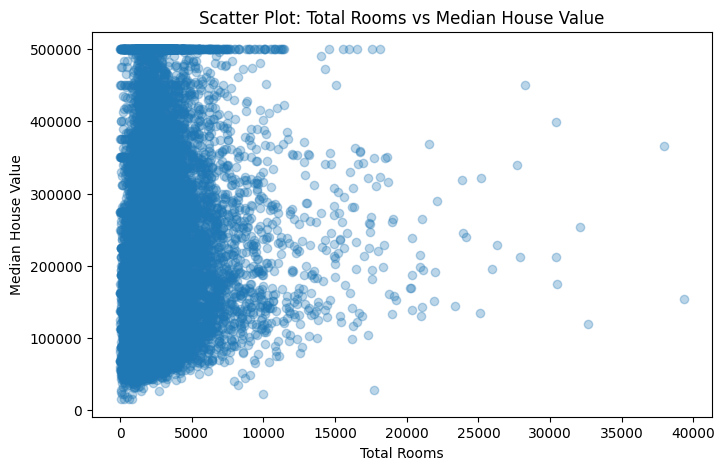

IQR for Total Rooms: 1700.25
IQR for Median House Value: 145125.0


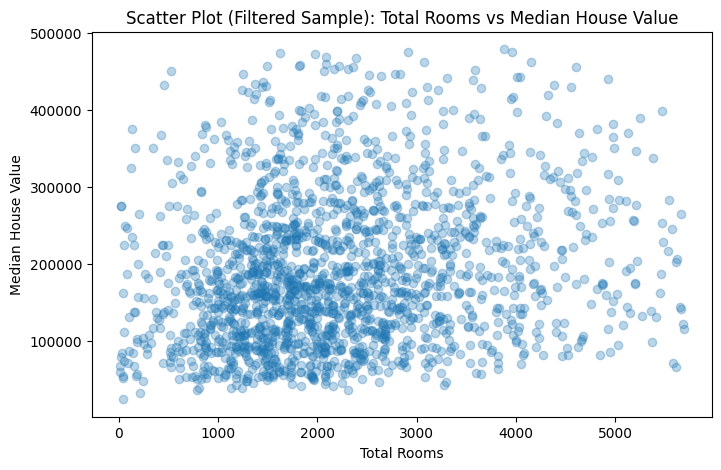

In [8]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(housing['total_rooms'], housing['median_house_value'], alpha=0.3)
plt.title("Scatter Plot: Total Rooms vs Median House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()

# Calcula el IQR para 'total_rooms'
Q1_rooms = housing['total_rooms'].quantile(0.25)
Q3_rooms = housing['total_rooms'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms
print("IQR for Total Rooms:", IQR_rooms)

# Calcula el IQR para 'median_house_value'
Q1_value = housing['median_house_value'].quantile(0.25)
Q3_value = housing['median_house_value'].quantile(0.75)
IQR_value = Q3_value - Q1_value
print("IQR for Median House Value:", IQR_value)

# Define los límites para considerar outliers
lower_limit_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_limit_rooms = Q3_rooms + 1.5 * IQR_rooms
lower_limit_value = Q1_value - 1.5 * IQR_value
upper_limit_value = Q3_value + 1.5 * IQR_value

# Filtra el DataFrame para eliminar outliers
housing_filtered = housing[
    (housing['total_rooms'] >= lower_limit_rooms) &
    (housing['total_rooms'] <= upper_limit_rooms) &
    (housing['median_house_value'] >= lower_limit_value) &
    (housing['median_house_value'] <= upper_limit_value)
]

# Toma una muestra del 10% de los datos
sample_data = housing_filtered.sample(frac=0.1, random_state=42)

# Scatter plot (Total Rooms vs Median House Value)
plt.figure(figsize=(8, 5))
plt.scatter(sample_data['total_rooms'], sample_data['median_house_value'], alpha=0.3)
plt.title("Scatter Plot (Filtered Sample): Total Rooms vs Median House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()


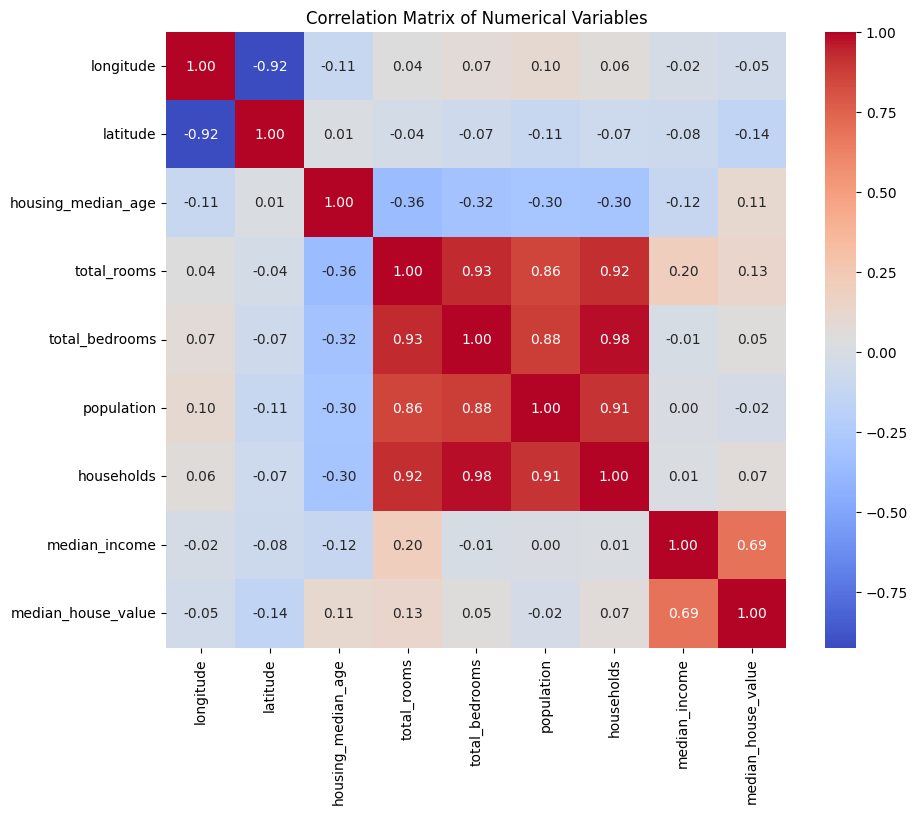

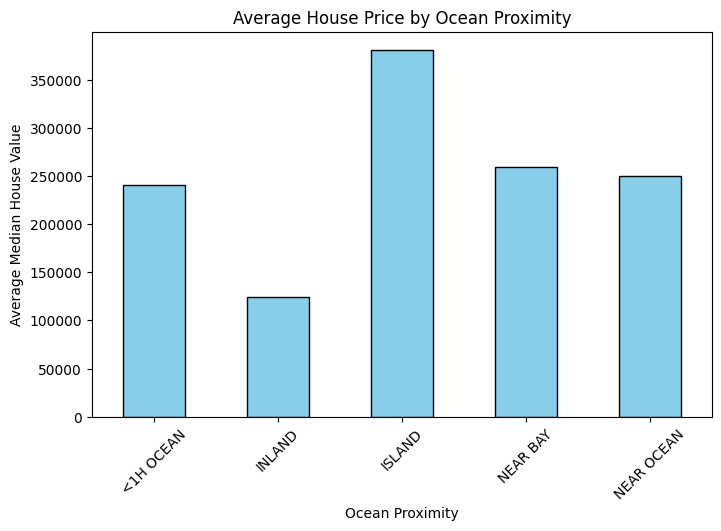

In [11]:
# Correlation matrix to identify influential variables
plt.figure(figsize=(10, 8))
numerical_features = housing.select_dtypes(include=['number'])  # Select numerical columns
correlation_matrix = numerical_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Bar chart to visualize the impact of ocean proximity on house prices
plt.figure(figsize=(8, 5))
avg_prices_by_proximity = housing.groupby('ocean_proximity')['median_house_value'].mean()
avg_prices_by_proximity.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average House Price by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Average Median House Value")
plt.xticks(rotation=45)
plt.show()

# Filter Methods

In [17]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import pandas as pd

# Load the housing dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing = pd.read_csv(url)

# Display the first few rows of the dataset
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
# Calculate the correlation matrix between numerical variables
numerical_features = housing.select_dtypes(include=['number'])
correlation_matrix = numerical_features.corr()

# Extract the correlations between numerical predictors and the target variable (median_house_value)
target_correlations = correlation_matrix["median_house_value"].drop("median_house_value")

# Sort the correlations in descending order to identify influential variables
sorted_correlations = target_correlations.sort_values(ascending=False)

# Display the influential variables
print("Correlations with Median House Value (sorted in descending order):")
print(sorted_correlations)


Correlations with Median House Value (sorted in descending order):
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [15]:
# Set a threshold for correlation coefficient (adjust as needed)
threshold = 0.5  # You can adjust this threshold based on your analysis needs

# Select influential variables based on the threshold
influential_variables = sorted_correlations[abs(sorted_correlations) >= threshold]

# Display the selected influential variables
print("Influential Variables with Correlation Coefficient >= Threshold:")
print(influential_variables)


Influential Variables with Correlation Coefficient >= Threshold:
median_income    0.688075
Name: median_house_value, dtype: float64


# Chi-Square Test

In [16]:
# Import libraries
import pandas as pd

# Create a sample dataset (you can replace this with your dataset)
data = {
    'Car_Model': ['Sedan', 'SUV', 'Sedan', 'SUV', 'Hatchback', 'SUV', 'Sedan', 'Hatchback', 'Sedan', 'SUV'],
    'Color': ['Red', 'Blue', 'Red', 'Blue', 'Red', 'Blue', 'Red', 'Red', 'Blue', 'Blue'],
    'Fuel_Type': ['Petrol', 'Diesel', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol'],
    'Decision': ['Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No']
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame(data)

# Display the dataset
df


,Car_Model,Color,Fuel_Type,Decision
0,Sedan,Red,Petrol,Yes
1,SUV,Blue,Diesel,Yes
2,Sedan,Red,Diesel,No
3,SUV,Blue,Petrol,No
4,Hatchback,Red,Diesel,Yes
5,SUV,Blue,Petrol,No
6,Sedan,Red,Petrol,No
7,Hatchback,Red,Diesel,Yes
8,Sedan,Blue,Petrol,Yes
9,SUV,Blue,Petrol,No


In [18]:
# Define a function to perform the chi-square test and return the p-value
def perform_chi_square_test(df, variable):
    contingency_table = pd.crosstab(df[variable], df['Decision'])
    print(f"\nContingency Table for {variable}:\n", contingency_table)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    return p

# List of categorical variables for testing
categorical_variables = ['Car_Model', 'Color', 'Fuel_Type']

# Perform the chi-square test for each categorical variable
chi_square_results = {}
for variable in categorical_variables:
    p_value = perform_chi_square_test(df, variable)
    chi_square_results[variable] = p_value

# Display the p-values for each variable
print("\nChi-Square Test Results:")
for variable, p_value in chi_square_results.items():
    print(f"{variable}: p-value = {p_value:.4f}")


Contingency Table for Car_Model:
 Decision   No  Yes
Car_Model         
Hatchback   0    2
SUV         3    1
Sedan       2    2

Contingency Table for Color:
 Decision  No  Yes
Color            
Blue       3    2
Red        2    3

Contingency Table for Fuel_Type:
 Decision   No  Yes
Fuel_Type         
Diesel      1    3
Petrol      4    2

Chi-Square Test Results:
Car_Model: p-value = 0.2231
Color: p-value = 1.0000
Fuel_Type: p-value = 0.5186


In [19]:
# Set a significance level threshold (adjust as needed)
significance_level = 0.05  # Commonly used threshold

# Select influential variables based on the significance level
influential_variables = {variable: p_value for variable, p_value in chi_square_results.items() if p_value < significance_level}

# Display the selected influential variables
print("\nInfluential Variables (p-value < significance level):")
for variable, p_value in influential_variables.items():
    print(f"{variable}: p-value = {p_value:.4f}")

if not influential_variables:
    print("No variables are significantly associated with the target variable at the given significance level.")



Influential Variables (p-value < significance level):
No variables are significantly associated with the target variable at the given significance level.


# Forward Selection

In [20]:
# Import libraries
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Display the first few rows of the dataset
data.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Split the dataset into features (X) and target (y)
X = data.drop(columns=['target'])
y = data['target']

# Initialize an empty list of selected variables
selected_variables = []

# Define the initial best accuracy as 0
best_accuracy = 0

# Specify the maximum number of iterations (number of variables)
max_iterations = X.shape[1]

# Create a function to train and evaluate the model
def train_and_evaluate(X, y, selected_variables):
    X_selected = X[selected_variables]
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Perform forward selection
for i in range(max_iterations):
    candidate_variables = [var for var in X.columns if var not in selected_variables]
    variable_accuracies = []

    for var in candidate_variables:
        accuracy = train_and_evaluate(X, y, selected_variables + [var])
        variable_accuracies.append((var, accuracy))
        print(f"Variable: {var}, Accuracy: {accuracy:.4f}")

    # Sort variables by accuracy in descending order
    variable_accuracies.sort(key=lambda x: x[1], reverse=True)

    # Select the best-performing variable from candidates
    best_variable, best_accuracy_candidate = variable_accuracies[0]

    # Check if the best candidate improves model accuracy
    if best_accuracy_candidate > best_accuracy:
        selected_variables.append(best_variable)
        best_accuracy = best_accuracy_candidate
    else:
        break

# Display the selected influential variables
print("\nSelected Influential Variables:")
print(selected_variables)
print(f"Best Model Accuracy: {best_accuracy:.4f}")


Variable: sepal length (cm), Accuracy: 0.8333
Variable: sepal width (cm), Accuracy: 0.6000
Variable: petal length (cm), Accuracy: 1.0000
Variable: petal width (cm), Accuracy: 1.0000
Variable: sepal length (cm), Accuracy: 1.0000
Variable: sepal width (cm), Accuracy: 1.0000
Variable: petal width (cm), Accuracy: 1.0000

Selected Influential Variables:
['petal length (cm)']
Best Model Accuracy: 1.0000


In [22]:
# Train the final model using the selected variables
X_final = X[selected_variables]
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
final_model = LogisticRegression(max_iter=200)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

# Display the final model's accuracy and selected variables
print("\nFinal Model Accuracy:", final_accuracy)
print("Selected Variables:", selected_variables)



Final Model Accuracy: 1.0
Selected Variables: ['petal length (cm)']


# Backward Elimination


Final Model Mean Squared Error: 2792.628207727037
Selected Variables: ['s5', 's6', 's3', 'bmi', 'sex']


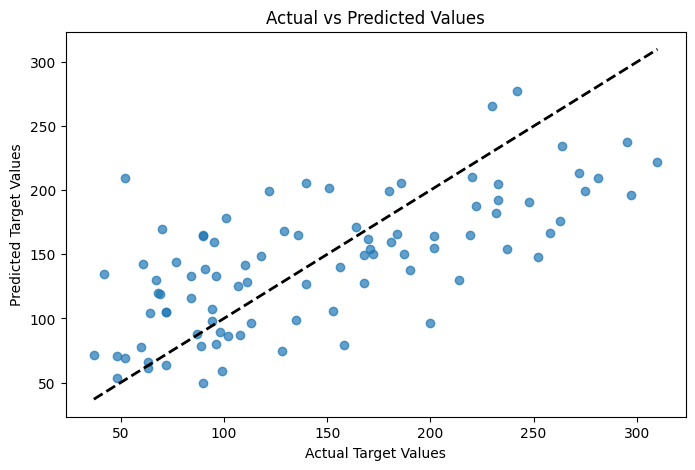

In [23]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt

# Load the Diabetes dataset
diabetes = load_diabetes()
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target

# Split the dataset into features (X) and target (y)
X = data.drop(columns=['target'])
y = data['target']

# Initialize a set of selected variables with all available variables
selected_variables = set(X.columns)

# Specify the maximum number of iterations (number of variables)
max_iterations = len(selected_variables)

# Define the initial best mean squared error as high
best_mse = float('inf')

# Define a function to train and evaluate the model
def train_and_evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse, model, X_test, y_test

# Perform backward elimination
for i in range(max_iterations):
    variable_mses = []

    for var in selected_variables:
        current_selected = list(selected_variables - {var})
        mse, _, _, _ = train_and_evaluate(X[current_selected], y)
        variable_mses.append((var, mse))

    # Sort variables by MSE in ascending order
    variable_mses.sort(key=lambda x: x[1])

    # Select the best-performing variable from candidates
    best_variable, best_mse_candidate = variable_mses[0]

    # Check if the best candidate improves model performance
    if best_mse_candidate < best_mse:
        selected_variables.remove(best_variable)
        best_mse = best_mse_candidate
    else:
        break

# Train the final model using the selected variables
final_mse, final_model, X_test, y_test = train_and_evaluate(X[list(selected_variables)], y)

# Display the final model's mean squared error and selected variables
print("\nFinal Model Mean Squared Error:", final_mse)
print("Selected Variables:", list(selected_variables))

# Plot the relationship between actual and predicted values
y_pred_final = final_model.predict(X_test)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_final, alpha=0.7)
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()


# Stepwise Selection

In [24]:
# Import libraries
import pandas as pd

# Load the Wine Quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=";")

# Display the first few rows of the dataset
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [27]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# Load the Wine Quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=";")

# Split the dataset into features (X) and target (y)
X = data.drop(columns=['quality'])
y = data['quality']

# Initialize an empty list of selected features
selected_features = []

# Create a function to train and evaluate the model
def train_and_evaluate(X, y, selected_features):
    X_with_constant = sm.add_constant(X[selected_features])
    model = sm.OLS(y, X_with_constant).fit()
    y_pred = model.predict(X_with_constant)
    mse = mean_squared_error(y, y_pred)
    return mse, model

# Perform stepwise feature selection
while True:
    candidate_features = [feature for feature in X.columns if feature not in selected_features]
    feature_mses = []

    for feature in candidate_features:
        mse, _ = train_and_evaluate(X, y, selected_features + [feature])
        feature_mses.append((feature, mse))

    # Sort features by MSE in ascending order
    feature_mses.sort(key=lambda x: x[1])

    # Select the best-performing feature from candidates
    best_feature, best_mse_candidate = feature_mses[0]

    # Check if the best candidate improves the model based on AIC
    _, current_model = train_and_evaluate(X, y, selected_features)
    current_aic = current_model.aic
    _, updated_model = train_and_evaluate(X, y, selected_features + [best_feature])
    updated_aic = updated_model.aic

    if updated_aic < current_aic:
        selected_features.append(best_feature)
    else:
        break

# Display the selected influential features
print("Selected Influential Features:")
print(selected_features)


Selected Influential Features:
['alcohol', 'volatile acidity', 'residual sugar', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'fixed acidity']


In [28]:
# Train the final model using the selected features
final_mse, final_model = train_and_evaluate(X, y, selected_features)

# Display the final model's Mean Squared Error and selected features
print("Final Model Mean Squared Error:", final_mse)
print("Selected Features:", selected_features)

# Display the summary of the final model (including coefficients)
print("\nFinal Model Summary:")
print(final_model.summary())


Final Model Mean Squared Error: 0.5632469120616972
Selected Features: ['alcohol', 'volatile acidity', 'residual sugar', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'fixed acidity']

Final Model Summary:
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     239.7
Date:                Mon, 28 Oct 2024   Prob (F-statistic):               0.00
Time:                        04:12:31   Log-Likelihood:                -5544.1
No. Observations:                4898   AIC:                         1.111e+04
Df Residuals:                    4889   BIC:                         1.116e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                        

# Integrated Feature Selection with Lasso Regression

In [29]:
# Import Libraries
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load the California Housing Prices dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of the dataset
X_train.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [30]:
# Import necessary libraries
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

# Initialize and fit a Lasso regression model with regularization parameter alpha
alpha = 0.1  # Adjust the regularization parameter as needed
lasso_model = Lasso(alpha=alpha)
lasso_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lasso_model.predict(X_test)

# Calculate Mean Squared Error to evaluate model performance
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Display selected features (with non-zero coefficients) for Lasso
selected_features = X.columns[lasso_model.coef_ != 0]
print("Selected Features with Non-Zero Coefficients:")
print(selected_features.tolist())


Mean Squared Error: 0.6135115198058131
Selected Features with Non-Zero Coefficients:
['MedInc', 'HouseAge', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [31]:
# Import necessary libraries
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Initialize and fit a Ridge regression model with regularization parameter alpha
alpha = 1.0  # Adjust the regularization parameter as needed
ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test)

# Calculate Mean Squared Error to evaluate model performance
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 0.5558034669932211
